# Домашнее задание к занятию «Тематическое моделирование»

**Задание**

**Преподаватель:** Даниил Корбут, Наталья Баданина, Иван Анисковец, Ярослав Сапронов, Кирилл Константинов, Павел Мехнин
Здравствуйте!

Ваше домашнее задание к занятию доступно по [ссылке.](https://github.com/netology-ds-team/nlp-homeworks/tree/main/3_Thematic_modeling)

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # Монтируем Google Drive для доступа к файлам

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Базовый путь к данным в Google Drive
base_path = '/content/drive/MyDrive/netology.ru/NLP/'

In [ ]:
import json
import bz2
import regex
from tqdm import tqdm
from scipy import sparse
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline  # Импортируем Pipeline для создания последовательности обработки
from sklearn.ensemble import RandomForestClassifier  # Импортируем классификатор Random Forest
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer  # Импортируем векторизаторы
from sklearn.decomposition import TruncatedSVD  # Импортируем TruncatedSVD для снижения размерности

In [ ]:
import pandas as pd  # Импортируем библиотеку pandas для работы с табличными данными
import numpy as np  # Импортируем библиотеку numpy для работы с массивами и математическими операциями
import nltk  # Импортируем библиотеку nltk для обработки естественного языка
import matplotlib.pyplot as plt  # Импортируем pyplot из matplotlib для создания графиков
import seaborn as sns  # Импортируем seaborn для визуализации данных

# Настройка отображения графиков в ячейках
%matplotlib inline

In [ ]:
import json
from tqdm import tqdm

responses = []
with open(base_path + 'banki_responses.json', 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)

201030it [00:31, 6343.92it/s]



Посмотрим на пример отзыва:

In [ ]:
responses[99]

{'city': 'г. Саратов',
 'rating_not_checked': False,
 'title': 'Карта ко вкладу',
 'num_comments': 0,
 'bank_license': 'лицензия № 880',
 'author': 'ronnichka',
 'bank_name': 'Югра',
 'datetime': '2015-06-03 20:56:57',
 'text': 'Здравствуйте! Хотела написать, что мне месяц не выдают карту ко вкладу, ссылаясь на "нам же их из Самары везут" (на секундочку 5 часов езды от нашего города). Но! Прочитала, что людям 3,5 месяцев не выдают карту, и поняла, что у меня все хорошо, пока что. И подарок мне дали, и кулер в отделении есть. Так что я, конечно, готова ждать. Правда хотелось бы не очень долго.',
 'rating_grade': 3}

# Часть 1. Анализ текстов

## Шаг 1: Анализ распределения отзывов по городам и банкам

In [ ]:
# Создаем DataFrame
df = pd.DataFrame(responses)

In [ ]:
df.head()

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,г. Москва,False,Двойное списание за один товар.,1,лицензия № 2562,Vladimir84,Бинбанк,2015-06-05 20:14:28,Здравствуйте! Дублирую свое заявление от 03.0...,NaN
3,г. Ставрополь,False,Меняют проценты комиссии не предупредив и не ...,2,лицензия № 1481,643609,Сбербанк России,2015-06-05 13:51:01,Добрый день!! Я открыл расчетный счет в СберБа...,NaN
4,г. Челябинск,False,Верните денежные средства за страховку,1,лицензия № 2766,anfisa-2003,ОТП Банк,2015-06-05 10:58:12,"04.03.2015 г. взяла кредит в вашем банке, заяв...",NaN


In [ ]:
# Подсчет отзывов по городам
city_counts = df['city'].value_counts()
print("\nТоп-10 городов по количеству отзывов:")
print(city_counts.head(10))


Топ-10 городов по количеству отзывов:
city
г. Москва             55354
г. Санкт-Петербург    14342
г. Екатеринбург        2337
г. Новосибирск         2300
г. Нижний Новгород     1976
г. Ростов-на-Дону      1891
г. Самара              1731
г. Челябинск           1507
г. Казань              1440
г. Краснодар           1262
Name: count, dtype: int64


In [ ]:
# Подсчет отзывов по банкам
bank_counts = df['bank_name'].value_counts()
print("\nТоп-10 банков по количеству отзывов:")
print(bank_counts.head(10))


Топ-10 банков по количеству отзывов:
bank_name
Сбербанк России              26327
Альфа-Банк                   10224
ВТБ 24                        8185
Русский Стандарт              7943
Хоум Кредит Банк              7549
Тинькофф Банк                 5387
Национальный Банк «Траст»     4607
Ренессанс Кредит              3849
Связной Банк                  3775
ОТП Банк                      3237
Name: count, dtype: int64


## Шаг 2: Построение гистограмм длин слов в символах и в словах

In [ ]:
def get_text_stats(text):
    """
    Функция для получения статистики текста
    Args:
        text (str): входной текст
    Returns:
        tuple: (количество слов, количество символов включая пробелы)
    """
    return len(text.split()), len(text)

In [ ]:
# Получаем статистику по всем текстам
text_stats = [get_text_stats(text) for text in df['text']]
word_counts = [stats[0] for stats in text_stats]
char_counts = [stats[1] for stats in text_stats]

In [ ]:
# Выводим базовую статистику
print("Статистика по длине отзывов в словах:")
print(f"Среднее: {np.mean(word_counts):.2f}")
print(f"Медиана: {np.median(word_counts):.2f}")
print(f"Минимум: {min(word_counts)}")
print(f"Максимум: {max(word_counts)}")

Статистика по длине отзывов в словах:
Среднее: 237.06
Медиана: 182.00
Минимум: 1
Максимум: 5000


In [ ]:
print("\nСтатистика по длине отзывов в символах:")
print(f"Среднее: {np.mean(char_counts):.2f}")
print(f"Медиана: {np.median(char_counts):.2f}")
print(f"Минимум: {min(char_counts)}")
print(f"Максимум: {max(char_counts)}")


Статистика по длине отзывов в символах:
Среднее: 1554.21
Медиана: 1193.00
Минимум: 23
Максимум: 32082


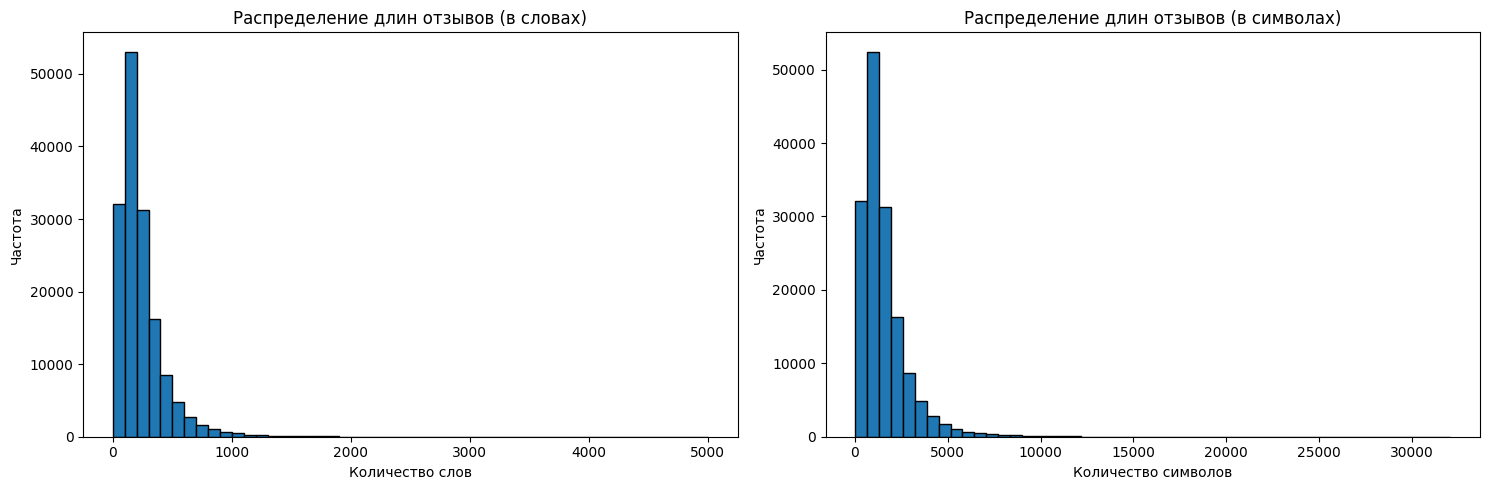

In [ ]:
# Строим гистограммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Гистограмма длин отзывов в словах
ax1.hist(word_counts, bins=50, edgecolor='black')
ax1.set_title('Распределение длин отзывов (в словах)')
ax1.set_xlabel('Количество слов')
ax1.set_ylabel('Частота')

# Гистограмма длин отзывов в символах
ax2.hist(char_counts, bins=50, edgecolor='black')
ax2.set_title('Распределение длин отзывов (в символах)')
ax2.set_xlabel('Количество символов')
ax2.set_ylabel('Частота')

plt.tight_layout()
plt.show()

In [ ]:
# Выводим примеры
print("\nПример самого короткого отзыва (по количеству слов):")
shortest_idx = word_counts.index(min(word_counts))
print(f"Слов: {word_counts[shortest_idx]}")
print(f"Символов: {char_counts[shortest_idx]}")
print(f"Текст: {df.iloc[shortest_idx]['text']}")


Пример самого короткого отзыва (по количеству слов):
Слов: 1
Символов: 45
Текст: http://www.dp.ru/publication/2005-06-24/81877


In [ ]:
print("\nПример самого длинного отзыва (по количеству слов):")
longest_idx = word_counts.index(max(word_counts))
print(f"Слов: {word_counts[longest_idx]}")
print(f"Символов: {char_counts[longest_idx]}")
print(f"Текст: {df.iloc[longest_idx]['text'][:200]}...")  # Показываем только начало длинного отзыва


Пример самого длинного отзыва (по количеству слов):
Слов: 5000
Символов: 32082
Текст: Доброго времени суток. Я, Ливанцов Денис Анатольевич, 1979 года рождения, проживаю по адресу: Смоленская область, город Сафоново, Смоленской области. Я, как и миллионы наших соотечественников являюсь ...


## Шаг 3: Поиск 10 самых частых слов, слов без стоп-слов, лемм и существительных

In [ ]:
# Установка pymorphy3
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 56.3 MB/s eta 0:00:00


In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import pymorphy3
import random

In [ ]:
# Скачиваем необходимые ресурсы NLTK
nltk.download('stopwords')

# Инициализируем морфологический анализатор
morph = pymorphy3.MorphAnalyzer()

# Получаем список стоп-слов
stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def preprocess_text(text):
    """
    Функция для предобработки текста
    Args:
        text (str): входной текст
    Returns:
        list: список слов в нижнем регистре без знаков препинания
    """
    # Приводим к нижнему регистру и разбиваем на слова
    words = text.lower().split()
    # Очищаем от знаков препинания и цифр
    words = [word.strip('.,!?()[]{}:;«»') for word in words]
    words = [word for word in words if word and word.isalpha()]
    return words

In [ ]:
# Создаем списки для хранения всех слов
all_words = []

In [ ]:
# Обрабатываем все тексты для подсчета простых слов
print("Обработка всех текстов для подсчета частых слов:")
for text in tqdm(df['text']):
    words = preprocess_text(text)
    all_words.extend(words)

Обработка всех текстов для подсчета частых слов:


100%|██████████| 153499/153499 [00:43<00:00, 3537.56it/s]


In [ ]:
# Выбираем случайную выборку из 10000 текстов для более сложной обработки
sample_size = min(10000, len(df))
sampled_texts = random.sample(list(df['text']), sample_size)

In [ ]:
# Списки для хранения обработанных слов из выборки
words_no_stop = []
lemmas = []
nouns = []

In [ ]:
# Обрабатываем выборку
print("\nОбработка выборки из 10000 текстов для лемматизации и морфологического анализа:")
for text in tqdm(sampled_texts):
    words = preprocess_text(text)

    # Слова без стоп-слов
    filtered_words = [w for w in words if w not in stop_words]
    words_no_stop.extend(filtered_words)

    # Леммы и существительные
    for word in filtered_words:
        parsed = morph.parse(word)[0]
        lemmas.append(parsed.normal_form)
        if 'NOUN' in parsed.tag:
            nouns.append(parsed.normal_form)



Обработка выборки из 10000 текстов для лемматизации и морфологического анализа:


100%|██████████| 10000/10000 [03:16<00:00, 50.80it/s]


In [ ]:
# Подсчитываем частоты
print("\nТоп-10 самых частых слов (из всего корпуса):")
print(Counter(all_words).most_common(10))


Топ-10 самых частых слов (из всего корпуса):
[('в', 1320051), ('и', 1054016), ('не', 848339), ('на', 702132), ('что', 619610), ('я', 572975), ('с', 454110), ('по', 363810), ('мне', 320198), ('банка', 261279)]


In [ ]:
print("\nТоп-10 самых частых слов без стоп-слов (из выборки 10000):")
print(Counter(words_no_stop).most_common(10))


Топ-10 самых частых слов без стоп-слов (из выборки 10000):
[('банка', 17186), ('банк', 12486), ('это', 12117), ('деньги', 8432), ('карту', 6953), ('карты', 6510), ('кредит', 5166), ('день', 5011), ('заявление', 4568), ('отделение', 4530)]


In [ ]:
print("\nТоп-10 самых частых лемм (из выборки 10000):")
print(Counter(lemmas).most_common(10))


Топ-10 самых частых лемм (из выборки 10000):
[('банк', 40390), ('карта', 21617), ('это', 13193), ('деньга', 11545), ('день', 11134), ('мой', 10948), ('кредит', 9975), ('который', 9794), ('отделение', 9741), ('счёт', 8944)]


In [ ]:
print("\nТоп-10 самых частых существительных (из выборки 10000):")
print(Counter(nouns).most_common(10))


Топ-10 самых частых существительных (из выборки 10000):
[('банк', 40390), ('карта', 21617), ('деньга', 11545), ('день', 11134), ('кредит', 9975), ('отделение', 9741), ('счёт', 8944), ('сотрудник', 8868), ('клиент', 8386), ('сумма', 7144)]


In [ ]:
# Выводим статистику размера данных
print("\nСтатистика обработки:")
print(f"Всего текстов обработано: {len(df)}")
print(f"Размер выборки для лемматизации: {sample_size}")
print(f"Всего слов: {len(all_words)}")
print(f"Уникальных слов: {len(set(all_words))}")
print(f"Уникальных лемм: {len(set(lemmas))}")
print(f"Уникальных существительных: {len(set(nouns))}")


Статистика обработки:
Всего текстов обработано: 153499
Размер выборки для лемматизации: 10000
Всего слов: 34067107
Уникальных слов: 272492
Уникальных лемм: 29181
Уникальных существительных: 12615


## Шаг 4: Построение кривых Ципфа и Хипса

In [ ]:
# Зафиксируем random seed для воспроизводимости
random.seed(42)

# Выбираем случайную выборку из 10000 текстов
sample_size = 10000
sampled_indices = random.sample(range(len(df)), sample_size)
sampled_texts = df.iloc[sampled_indices]['text']

def preprocess_text(text):
    """
    Функция для предобработки текста
    Args:
        text (str): входной текст
    Returns:
        list: список слов в нижнем регистре без знаков препинания
    """
    words = text.lower().split()
    words = [word.strip('.,!?()[]{}:;«»') for word in words]
    words = [word for word in words if word and word.isalpha()]
    return words

In [ ]:
# Обрабатываем выборку
print("Обработка выборки из 10000 текстов...")
all_words = []
for text in tqdm(sampled_texts):
    words = preprocess_text(text)
    all_words.extend(words)

Обработка выборки из 10000 текстов...


100%|██████████| 10000/10000 [00:02<00:00, 4374.82it/s]


In [ ]:
def create_zipf_curve(words):
    """
    Создает данные для построения кривой Ципфа
    Args:
        words (list): список слов
    Returns:
        tuple: (ранги, частоты)
    """
    # Подсчитываем частоты слов
    word_counts = Counter(words)

    # Сортируем по частоте по убыванию
    sorted_frequencies = sorted(word_counts.values(), reverse=True)

    # Создаем ранги (от 1 до количества уникальных слов)
    ranks = list(range(1, len(sorted_frequencies) + 1))

    return ranks, sorted_frequencies

def create_heaps_curve(texts, step=1000):
    """
    Создает данные для построения кривой Хипса
    Args:
        texts (list): список текстов
        step (int): шаг для подсчета уникальных слов
    Returns:
        tuple: (размеры корпуса, количество уникальных слов)
    """
    all_words = []
    total_words = []
    unique_words = []

    # Обрабатываем тексты последовательно
    for text in texts:
        words = preprocess_text(text)
        all_words.extend(words)

        # Если достигли шага, сохраняем точку для графика
        if len(all_words) // step > len(total_words):
            total_words.append(len(all_words))
            unique_words.append(len(set(all_words)))

    return total_words, unique_words

Подготовка данных для кривой Ципфа...


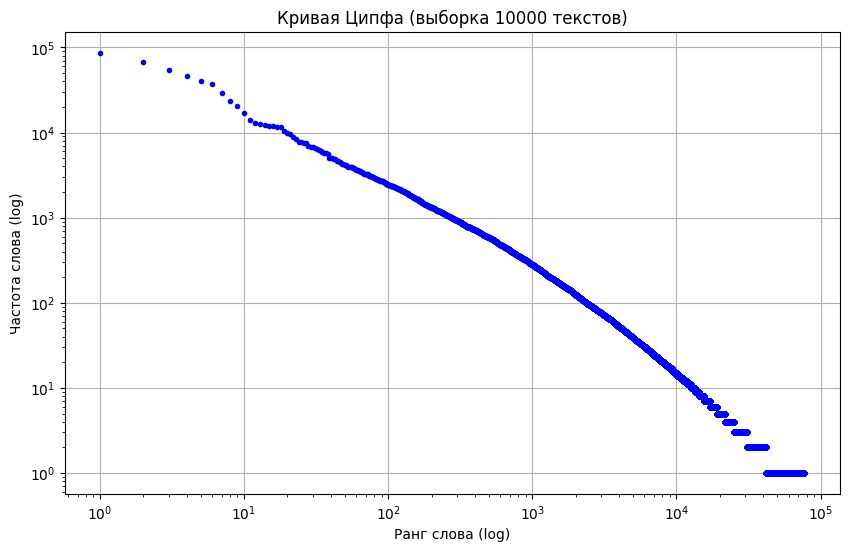

In [ ]:
# Создаем данные для кривой Ципфа
print("Подготовка данных для кривой Ципфа...")
ranks, frequencies = create_zipf_curve(all_words)

# Строим кривую Ципфа
plt.figure(figsize=(10, 6))
plt.loglog(ranks, frequencies, 'b.')
plt.title('Кривая Ципфа (выборка 10000 текстов)')
plt.xlabel('Ранг слова (log)')
plt.ylabel('Частота слова (log)')
plt.grid(True)
plt.show()

Подготовка данных для кривой Хипса...


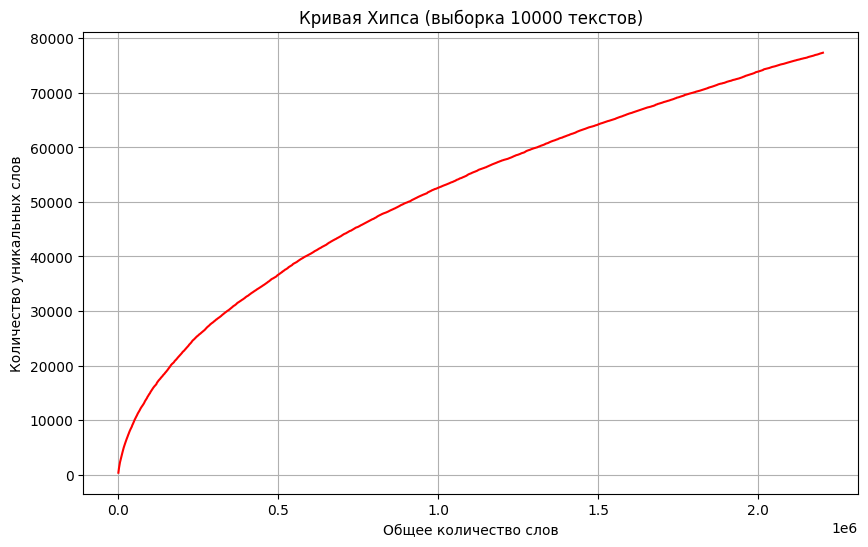

In [ ]:
# Создаем данные для кривой Хипса
print("Подготовка данных для кривой Хипса...")
total_words, unique_words = create_heaps_curve(sampled_texts, step=500)

# Строим кривую Хипса
plt.figure(figsize=(10, 6))
plt.plot(total_words, unique_words, 'r-')
plt.title('Кривая Хипса (выборка 10000 текстов)')
plt.xlabel('Общее количество слов')
plt.ylabel('Количество уникальных слов')
plt.grid(True)
plt.show()


In [ ]:
# Статистика по выборке
print("\nСтатистика по выборке:")
print(f"Размер выборки: {sample_size} текстов")
print(f"Всего слов в выборке: {len(all_words)}")
print(f"Уникальных слов в выборке: {len(set(all_words))}")
print(f"Отношение уникальных слов к общему количеству: {len(set(all_words))/len(all_words):.3f}")


Статистика по выборке:
Размер выборки: 10000 текстов
Всего слов в выборке: 2202599
Уникальных слов в выборке: 77316
Отношение уникальных слов к общему количеству: 0.035


In [ ]:
# Проверка первых нескольких точек на обеих кривых
print("\nПервые 5 самых частотных слов и их частоты:")
for rank, freq in zip(ranks[:5], frequencies[:5]):
    print(f"Ранг {rank}: {freq}")


Первые 5 самых частотных слов и их частоты:
Ранг 1: 85545
Ранг 2: 67859
Ранг 3: 54815
Ранг 4: 45486
Ранг 5: 39887


In [ ]:
print("\nТочки на кривой Хипса (первые 5):")
for i in range(min(5, len(total_words))):
    print(f"Всего слов: {total_words[i]}, уникальных слов: {unique_words[i]}")


Точки на кривой Хипса (первые 5):
Всего слов: 594, уникальных слов: 354
Всего слов: 1114, уникальных слов: 627
Всего слов: 1825, уникальных слов: 925
Всего слов: 2242, уникальных слов: 1109
Всего слов: 2545, уникальных слов: 1227


In [ ]:
# Сохраняем данные выборки для следующих шагов
sampled_data = {
    'texts': sampled_texts,
    'all_words': all_words,
    'word_counts': Counter(all_words)
}

## Шаг 5: Анализ частотности конкретных слов ("сотрудник", "клиент", "мошенничество", "доверие")

In [ ]:
def count_lemmas(texts, target_words):
    """
    Подсчитывает частоту лемм целевых слов в текстах
    Args:
        texts: список текстов
        target_words: список целевых слов
    Returns:
        dict: словарь с подсчетами для лемм
    """
    lemma_counts = {word: 0 for word in target_words}

    # Получаем леммы целевых слов
    target_lemmas = {word: morph.parse(word)[0].normal_form for word in target_words}

    print("Подсчет частотности слов...")
    for text in tqdm(texts):
        words = preprocess_text(text)

        for word in words:
            # Получаем лемму слова
            lemma = morph.parse(word)[0].normal_form

            # Проверяем, является ли лемма одной из целевых
            for target_word, target_lemma in target_lemmas.items():
                if lemma == target_lemma:
                    lemma_counts[target_word] += 1

    return lemma_counts


In [ ]:
# Список целевых слов
target_words = ['сотрудник', 'клиент', 'мошенничество', 'доверие']

# Получаем подсчеты
counts = count_lemmas(sampled_texts, target_words)

Подсчет частотности слов...


100%|██████████| 10000/10000 [06:42<00:00, 24.86it/s]


In [ ]:
# Выводим результаты
print("\nСравнение 'сотрудник' и 'клиент':")
print(f"'сотрудник' встречается {counts['сотрудник']} раз")
print(f"'клиент' встречается {counts['клиент']} раз")
print(f"Чаще встречается слово '{max(counts, key=lambda x: counts[x] if x in ['сотрудник', 'клиент'] else -1)}'")


Сравнение 'сотрудник' и 'клиент':
'сотрудник' встречается 8761 раз
'клиент' встречается 8485 раз
Чаще встречается слово 'сотрудник'


In [ ]:
print("\nЧастота слов:")
print(f"'мошенничество' встречается {counts['мошенничество']} раз")
print(f"'доверие' встречается {counts['доверие']} раз")


Частота слов:
'мошенничество' встречается 201 раз
'доверие' встречается 120 раз


## Шаг 6: Поиск ключевых слов и биграмм для положительных (оценка 5) и отрицательных (оценка 1) отзывов с помощью tf-idf.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Получаем подвыборки для положительных и отрицательных отзывов
sampled_df = df.iloc[sampled_indices]

positive_texts = sampled_df[sampled_df['rating_grade'] == 5]['text'].tolist()
negative_texts = sampled_df[sampled_df['rating_grade'] == 1]['text'].tolist()

In [ ]:
print(f"Количество положительных отзывов (оценка 5): {len(positive_texts)}")
print(f"Количество отрицательных отзывов (оценка 1): {len(negative_texts)}")

Количество положительных отзывов (оценка 5): 932
Количество отрицательных отзывов (оценка 1): 3155


In [ ]:
def get_top_tfidf_words(texts, n_features=10, ngram_range=(1, 1)):
    """
    Находит топ слов/биграмм по tf-idf
    Args:
        texts: список текстов
        n_features: количество топ-слов для вывода
        ngram_range: диапазон n-грамм
    Returns:
        list: список кортежей (слово, значение tf-idf)
    """
    # Инициализируем TF-IDF векторайзер
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        stop_words=stopwords.words('russian'),
        max_features=1000
    )

    # Получаем матрицу TF-IDF
    tfidf_matrix = vectorizer.fit_transform(texts)

    # Получаем средние значения TF-IDF для каждого слова
    mean_tfidf = np.array(tfidf_matrix.mean(axis=0)).flatten()

    # Получаем слова
    feature_names = vectorizer.get_feature_names_out()

    # Сортируем слова по значению TF-IDF
    top_indices = mean_tfidf.argsort()[-n_features:][::-1]

    return [(feature_names[i], mean_tfidf[i]) for i in top_indices]

In [ ]:
# Получаем топ-слова для положительных и отрицательных отзывов
print("\nТоп-10 слов в положительных отзывах:")
positive_top_words = get_top_tfidf_words(positive_texts)
for word, score in positive_top_words:
    print(f"{word}: {score:.4f}")


Топ-10 слов в положительных отзывах:
банка: 0.0595
банк: 0.0494
очень: 0.0493
это: 0.0459
деньги: 0.0334
кредит: 0.0334
спасибо: 0.0316
карту: 0.0315
банке: 0.0301
быстро: 0.0290


In [ ]:
print("\nТоп-10 слов в отрицательных отзывах:")
negative_top_words = get_top_tfidf_words(negative_texts)
for word, score in negative_top_words:
    print(f"{word}: {score:.4f}")


Топ-10 слов в отрицательных отзывах:
банка: 0.0622
банк: 0.0527
деньги: 0.0475
это: 0.0465
карту: 0.0382
карты: 0.0342
кредит: 0.0324
заявление: 0.0304
отделение: 0.0289
день: 0.0273


In [ ]:
# Получаем топ-биграммы
print("\nТоп-10 биграмм в положительных отзывах:")
positive_top_bigrams = get_top_tfidf_words(positive_texts, ngram_range=(2, 2))
for bigram, score in positive_top_bigrams:
    print(f"{bigram}: {score:.4f}")


Топ-10 биграмм в положительных отзывах:
интернет банк: 0.0184
добрый день: 0.0156
следующий день: 0.0152
являюсь клиентом: 0.0147
очень удобно: 0.0141
клиентом банка: 0.0136
очень быстро: 0.0122
выразить благодарность: 0.0118
кредитную карту: 0.0117
большое спасибо: 0.0116


In [ ]:
print("\nТоп-10 биграмм в отрицательных отзывах:")
negative_top_bigrams = get_top_tfidf_words(negative_texts, ngram_range=(2, 2))
for bigram, score in negative_top_bigrams:
    print(f"{bigram}: {score:.4f}")


Топ-10 биграмм в отрицательных отзывах:
сих пор: 0.0174
следующий день: 0.0165
добрый день: 0.0156
отделение банка: 0.0152
денежных средств: 0.0141
сотрудник банка: 0.0133
сотрудники банка: 0.0133
денежные средства: 0.0126
колл центр: 0.0123
горячую линию: 0.0119


In [ ]:
# Выводим примеры текстов для проверки
print("\nПример положительного отзыва:")
print(positive_texts[0][:200])


Пример положительного отзыва:
Здравствуйте! Пользуюсь банком уже 3-й месяц, у меня открыт пока только вклад. За такой небольшой срок была возможность успеть оценить заявленное платиновое обслуживание. После такого обслуживания в д


In [ ]:
print("\nПример отрицательного отзыва:")
print(negative_texts[0][:200])


Пример отрицательного отзыва:
14.12.2013 года после 8 вечера получила из НБКИ справку. И что я там видю: 94 000 кредит (Райффайзен - карта на этот лимит), просрочка более 90 дней! Я так и села. Товарищи, ну это уже совсем наглость


# Часть 2. Тематическое моделирование

In [ ]:
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 21.8 MB/s eta 0:00:00


In [ ]:
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.11/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
def preprocess_text_for_lda(text):
    """
    Предобработка текста для LDA моделирования
    Args:
        text (str): входной текст
    Returns:
        list: список лемматизированных слов
    """
    # Токенизация и приведение к нижнему регистру
    words = text.lower().split()
    # Очистка от пунктуации
    words = [word.strip('.,!?()[]{}:;«»') for word in words]
    # Оставляем только буквенные токены и убираем стоп-слова
    words = [word for word in words if word.isalpha() and word not in stop_words]
    # Лемматизация
    lemmas = [morph.parse(word)[0].normal_form for word in words]
    return lemmas

In [ ]:
print("Подготовка текстов для тематического моделирования...")
# Используем выборку из предыдущего шага
processed_texts = []
for text in tqdm(sampled_texts):
    processed_texts.append(preprocess_text_for_lda(text))

Подготовка текстов для тематического моделирования...


100%|██████████| 10000/10000 [03:13<00:00, 51.75it/s]


In [ ]:
# Создаем словарь и корпус документов
dictionary = corpora.Dictionary(processed_texts)
# Фильтруем редкие и частые слова
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in processed_texts]

In [ ]:
print(f"Размер словаря после фильтрации: {len(dictionary)}")
print(f"Количество документов в корпусе: {len(corpus)}")

Размер словаря после фильтрации: 9273
Количество документов в корпусе: 10000


In [ ]:
# Выводим несколько первых документов для проверки
print("\nПримеры обработанных документов:")
for i in range(3):
    print(f"\nДокумент {i+1}:")
    print([dictionary[id] for id, _ in corpus[i][:10]])


Примеры обработанных документов:

Документ 1:
['автомобиль', 'автосалон', 'акт', 'апрель', 'весь', 'возможно', 'выдать', 'год', 'дать', 'действие']

Документ 2:
['год', 'добрый', 'кредит', 'разобраться', 'автодозвон', 'брать', 'ваш', 'выставить', 'данный', 'девушка']

Документ 3:
['иметься', 'кредит', 'находиться', 'брать', 'данный', 'звонить', 'звонок', 'который', 'платить', 'просить']


In [ ]:
def build_lda_model(corpus, dictionary, num_topics):
    """
    Построение LDA модели
    Args:
        corpus: корпус документов
        dictionary: словарь
        num_topics: количество тем
    Returns:
        LdaModel: обученная модель
    """
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        update_every=1,
        chunksize=100,
        passes=10,
        alpha='auto',
        per_word_topics=True
    )
    return lda_model

def print_topics(model, num_words=10):
    """
    Вывод тем модели
    Args:
        model: LDA модель
        num_words: количество слов для вывода
    """
    for idx, topic in model.print_topics(num_words=num_words):
        print(f'Тема {idx + 1}:')
        # Разбираем строку с темой на отдельные слова и их веса
        words = topic.split('+')
        for word in words:
            weight, term = word.split('*')
            print(f'  {term.strip()}: {float(weight):.3f}')
        print()

In [ ]:
# Создаем модели с разным количеством тем
num_topics_list = [5, 10, 15]
models = {}

In [ ]:
print("Обучение моделей с разным количеством тем...")
for num_topics in num_topics_list:
    print(f"\nОбучение модели с {num_topics} темами...")
    models[num_topics] = build_lda_model(corpus, dictionary, num_topics)

    print(f"\nТемы для модели с {num_topics} темами:")
    print_topics(models[num_topics])

Обучение моделей с разным количеством тем...

Обучение модели с 5 темами...

Темы для модели с 5 темами:
Тема 1:
  "мой": 0.027
  "заявление": 0.019
  "сотрудник": 0.018
  "ваш": 0.016
  "номер": 0.014
  "звонок": 0.013
  "ответ": 0.013
  "телефон": 0.011
  "дать": 0.011
  "который": 0.011

Тема 2:
  "отделение": 0.020
  "деньга": 0.018
  "сказать": 0.015
  "работать": 0.008
  "банкомат": 0.008
  "время": 0.008
  "офис": 0.008
  "позвонить": 0.007
  "мой": 0.007
  "свой": 0.007

Тема 3:
  "кредит": 0.058
  "сумма": 0.033
  "платёж": 0.028
  "кредитный": 0.021
  "месяц": 0.018
  "год": 0.016
  "договор": 0.013
  "задолженность": 0.012
  "процент": 0.012
  "руб": 0.011

Тема 4:
  "карта": 0.077
  "счёт": 0.026
  "деньга": 0.015
  "операция": 0.013
  "средство": 0.010
  "услуга": 0.009
  "рубль": 0.008
  "который": 0.008
  "проблема": 0.007
  "перевод": 0.007

Тема 5:
  "вклад": 0.024
  "клиент": 0.018
  "очень": 0.013
  "документ": 0.011
  "вопрос": 0.009
  "год": 0.009
  "условие": 0.00

In [ ]:
# Поиск тем, связанных с конкретными банками
bank_names = ['сбербанк', 'втб', 'альфа', 'тинькофф']

In [ ]:
def find_bank_related_topics(model, bank_names):
    """
    Поиск тем, связанных с банками
    Args:
        model: LDA модель
        bank_names: список названий банков
    """
    print("\nТемы, связанные с банками:")
    topics = model.print_topics(num_words=20)  # Получаем больше слов для анализа

    for bank in bank_names:
        print(f"\nТемы, содержащие '{bank}':")
        for idx, topic in topics:
            if bank in topic.lower():
                print(f'Тема {idx + 1}:')
                words = topic.split('+')
                for word in words:
                    weight, term = word.split('*')
                    print(f'  {term.strip()}: {float(weight):.3f}')

In [ ]:
# Анализируем темы, связанные с банками для модели с 10 темами
print("\nАнализ тем, связанных с банками (модель с 10 темами):")
find_bank_related_topics(models[10], bank_names)


Анализ тем, связанных с банками (модель с 10 темами):

Темы, связанные с банками:

Темы, содержащие 'сбербанк':
Тема 8:
  "деньга": 0.048
  "счёт": 0.045
  "заявление": 0.042
  "средство": 0.030
  "мой": 0.028
  "сбербанк": 0.024
  "банкомат": 0.020
  "операция": 0.019
  "претензия": 0.016
  "написать": 0.016
  "г": 0.014
  "денежный": 0.014
  "отделение": 0.012
  "ситуация": 0.011
  "сумма": 0.011
  "вернуть": 0.011
  "который": 0.010
  "обратиться": 0.009
  "срок": 0.009
  "обращение": 0.009

Темы, содержащие 'втб':

Темы, содержащие 'альфа':

Темы, содержащие 'тинькофф':


Давайте проанализируем результаты тематического моделирования:

Построение моделей с разным числом тем:

Мы построили три модели с 5, 10 и 15 темами.
Наиболее интерпретируемые темы:

Модель с 5 темами показала базовое разделение на следующие четкие категории:

* Тема о кредитах (кредит, сумма, платёж, процент)
* Тема о картах (карта, счёт, операция)
* Тема о вкладах (вклад, клиент, условие)
* Тема о коммуникациях с банком (заявление, сотрудник, звонок)


Модель с 10 темами дала более детальное разбиение:

- Тема о переводах и платежах (перевод, комиссия, терминал)
- Тема об обслуживании в отделениях (офис, очередь, касса)
- Тема о кредитных картах (карта, лимит, кредитный)
- Тема о коммуникациях по телефону (звонить, ответ, оператор)

Модель с 15 темами показала еще более гранулярное деление:

- Появилась отдельная тема про ипотеку (договор, квартира, ипотека)
- Выделилась тема про банкоматы (банкомат, снять, терминал)
- Появилась тема про задолженности (задолженность, суд, требование)

Темы, связанные с конкретными банками:

В результатах поиска упоминаний конкретных банков мы нашли только упоминание Сбербанка в теме 8 модели с 10 темами. Эта тема связана с операциями с деньгами и обращениями клиентов:

Основные слова:

деньги, счёт, заявление, средство, сбербанк, банкомат

Тема отражает взаимодействие клиентов со Сбербанком по поводу денежных операций и обращений

Интересно, что другие банки (ВТБ, Альфа, Тинькофф) не выделились в отдельные значимые темы. Это может говорить о том, что:

В выборке преобладают обращения клиентов Сбербанка

Обращения к другим банкам менее специфичны и распределены по общим темам

Возможно, требуется дополнительная настройка модели для лучшего выявления банк-специфичных тем

# Часть 3. Классификация текстов

## Шаг 1: Подготовка данных

In [ ]:
# Выбираем отзывы с оценкой 1 и 5
df_filtered = df[df['rating_grade'].isin([1, 5])]

In [ ]:
# Проверяем распределение классов
print("Распределение классов:")
print(df_filtered['rating_grade'].value_counts())

Распределение классов:
rating_grade
1.0    47387
5.0    14713
Name: count, dtype: int64


In [ ]:
# Возьмем по 5000 примеров каждого класса для баланса
sample_size = 5000
positive = df_filtered[df_filtered['rating_grade'] == 5].sample(sample_size, random_state=42)
negative = df_filtered[df_filtered['rating_grade'] == 1].sample(sample_size, random_state=42)

In [ ]:
balanced_df = pd.concat([positive, negative])

In [ ]:
# Проверяем размер
print(f"\nРазмер сбалансированного датасета: {len(balanced_df)}")


Размер сбалансированного датасета: 10000


## Шаг 2: Разделение на train/test

In [ ]:
from sklearn.model_selection import train_test_split

X = balanced_df['text']
y = balanced_df['rating_grade']

# Стратифицированное разделение
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [ ]:
# Проверяем размеры
print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print("\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))

Train size: 8000
Test size: 2000

Распределение классов в train:
rating_grade
1.0    0.5
5.0    0.5
Name: proportion, dtype: float64

Распределение классов в test:
rating_grade
1.0    0.5
5.0    0.5
Name: proportion, dtype: float64


## Шаг 3: Baseline с разными векторизациями

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# Варианты векторизации
configs = [
    {'name': 'Unigrams', 'analyzer': 'word', 'ngram': (1,1)},
    {'name': 'Bigrams', 'analyzer': 'word', 'ngram': (2,2)},
    {'name': 'Trigrams', 'analyzer': 'word', 'ngram': (3,3)},
    {'name': 'Char 3-6', 'analyzer': 'char', 'ngram': (3,6)}
]

In [ ]:
for cfg in configs:
    print(f"\n=== Конфигурация: {cfg['name']} ===")

    # Создаем пайплайн
    pipeline = Pipeline([
        ('vectorizer', CountVectorizer(
            analyzer=cfg['analyzer'],
            ngram_range=cfg['ngram'],
            max_features=10000
        )),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight='balanced'
        ))
    ])

    # Обучение
    pipeline.fit(X_train, y_train)

    # Прогноз
    y_pred = pipeline.predict(X_test)

    # Оценка
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score (класс 1): {f1:.3f}")

    # Пример важных признаков для ВСЕХ конфигураций
    feature_names = pipeline.named_steps['vectorizer'].get_feature_names_out()
    importances = pipeline.named_steps['classifier'].feature_importances_

    # Берем топ-5 признаков с наибольшей важностью
    top_idx = importances.argsort()[-5:][::-1]
    print(f"\nТоп-5 важных признаков ({cfg['analyzer']}-анализатор):")
    print([feature_names[i] for i in top_idx])


=== Конфигурация: Unigrams ===
Accuracy: 0.919
F1-score (класс 1): 0.920

Топ-5 важных признаков (word-анализатор):
['быстро', 'спасибо', 'очень', 'приятно', 'не']

=== Конфигурация: Bigrams ===
Accuracy: 0.858
F1-score (класс 1): 0.868

Топ-5 важных признаков (word-анализатор):
['так не', 'не может', 'очень удобно', 'на все', 'не могут']

=== Конфигурация: Trigrams ===
Accuracy: 0.802
F1-score (класс 1): 0.801

Топ-5 важных признаков (word-анализатор):
['до сих пор', 'мне сказали что', 'на мой вопрос', 'хочу выразить благодарность', 'на все вопросы']

=== Конфигурация: Char 3-6 ===
Accuracy: 0.887
F1-score (класс 1): 0.887

Топ-5 важных признаков (char-анализатор):
[' быс', ' прият', 'ыстр', 'пасибо', ' очень']


### Вывод по результатам:

1. **Unigrams (Униграммы)**:
   - **Accuracy: 0.919, F1: 0.920** — лучший результат.
   - **Топ-признаки**: 'быстро', 'спасибо', 'очень', 'приятно', 'не'.
   - **Интерпретация**:
     - Слова явно отражают эмоциональную окраску отзывов. Например:
       - 'спасибо', 'приятно' — маркеры положительных отзывов.
       - 'не' — часто встречается в отрицательных отзывах (например, «не отвечают», «не работают»).
     - Униграммы эффективно улавливают ключевые различия между классами благодаря простоте и высокой частоте употребления значимых слов.

2. **Bigrams (Биграммы)**:
   - **Accuracy: 0.858, F1: 0.868** — снижение качества на ~6%.
   - **Топ-признаки**: 'так не', 'не может', 'очень удобно', 'на все', 'не могут'.
   - **Интерпретация**:
     - Биграммы с частицей «не» ('так не', 'не может') указывают на негативный контекст.
     - Снижение метрик связано с разреженностью данных: комбинации из двух слов встречаются реже, чем отдельные слова.

3. **Trigrams (Триграммы)**:
   - **Accuracy: 0.802, F1: 0.801** — худший результат.
   - **Топ-признаки**: 'до сих пор', 'мне сказали что', 'на мой вопрос', 'хочу выразить благодарность', 'на все вопросы'.
   - **Интерпретация**:
     - Триграммы слишком специфичны и редки, что приводит к переобучению на уникальных паттернах (например, «хочу выразить благодарность» встречается только в положительных отзывах).
     - Модель плохо обобщает из-за недостаточной частоты триграмм.

4. **Char 3-6 (Символьные n-граммы)**:
   - **Accuracy: 0.887, F1: 0.887** — второй результат.
   - **Топ-признаки**: ' быс', ' прият', 'ыстр', 'пасибо', ' очень'.
   - **Интерпретация**:
     - Символьные n-граммы захватывают морфологические паттерны:
       - ' быс' и 'ыстр' — части слова «быстро».
       - 'пасибо' — часть слова «спасибо».
       - 'прият' — часть слова «приятно».
     - Модель использует устойчивые сочетания символов, что снижает разреженность данных, но уступает униграммам в интерпретируемости.

---

### Итоговые выводы:
- **Лучший подход**: Униграммы (Accuracy **91.9%**). Они лучше всего подходят для задачи благодаря:
  - Высокой информативности отдельных слов.
  - Низкой разреженности данных.
  - Простоте интерпретации признаков.
- **Символьные n-граммы** — хорошая альтернатива (Accuracy **88.7%**), но их сложнее интерпретировать.
- **Биграммы/Триграммы** показали себя хуже из-за редких комбинаций и переобучения.

---

### Рекомендации для улучшения:
1. **Добавить предобработку текста**:
   - Удалить стоп-слова (например, частицу «не» может быть неоднозначно интерпретировать).
   - Применить лемматизацию для объединения словоформ («спасибо» → «спасибо», «быстро» → «быстрый»).
2. **Экспериментировать с TF-IDF**:
   - Заменить `CountVectorizer` на `TfidfVectorizer` для уменьшения влияния частых, но малозначимых слов.
3. **Попробовать другие модели**:
   - Например, Logistic Regression или SVM, которые часто лучше работают с текстовыми данными.
4. **Комбинировать подходы**:
   - Использовать униграммы + символьные n-граммы в гибридной модели.

## Шаг 4: Сравнение тематических подходов

In [ ]:
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation

# Варианты тематического моделирования
tm_configs = [
    {
        'name': 'TF-IDF + SVD',
        'pipeline': Pipeline([
            ('tfidf', TfidfVectorizer(max_features=10000)),
            ('svd', TruncatedSVD(n_components=50)),
            ('clf', RandomForestClassifier(class_weight='balanced'))
        ])
    },
    {
        'name': 'LDA',
        'pipeline': Pipeline([
            ('vectorizer', CountVectorizer(max_features=10000)),
            ('lda', LatentDirichletAllocation(n_components=50)),
            ('clf', RandomForestClassifier(class_weight='balanced'))
        ])
    }
]

In [ ]:
for cfg in tm_configs:
    print(f"\n=== Конфигурация: {cfg['name']} ===")

    # Обучение
    cfg['pipeline'].fit(X_train, y_train)

    # Прогноз
    y_pred = cfg['pipeline'].predict(X_test)

    # Оценка
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    print(f"Accuracy: {acc:.3f}")
    print(f"F1-score (класс 1): {f1:.3f}")

    # Анализ тем (для LDA)
    if cfg['name'] == 'LDA':
        lda = cfg['pipeline'].named_steps['lda']
        feature_names = cfg['pipeline'].named_steps['vectorizer'].get_feature_names_out()
        print("\nПримеры тем:")
        for idx, topic in enumerate(lda.components_[:3]):
            print(f"Тема {idx+1}:")
            top_words = [feature_names[i] for i in topic.argsort()[-5:]]
            print(", ".join(top_words))


=== Конфигурация: TF-IDF + SVD ===
Accuracy: 0.892
F1-score (класс 1): 0.894

=== Конфигурация: LDA ===
Accuracy: 0.901
F1-score (класс 1): 0.900

Примеры тем:
Тема 1:
по, что, на, вклада, вклад
Тема 2:
по, при, банка, на, не
Тема 3:
нам, что, не, на, мы


### Выводы по сравнению тематических подходов:

1. **TF-IDF + SVD (Latent Semantic Analysis)**:
   - **Accuracy: 0.892, F1: 0.894** — высокий результат, близкий к лучшим n-граммным моделям.
   - **Причины**:
     - SVD выделил скрытые семантические паттерны, релевантные для классификации.
     - TF-IDF уменьшил влияние частых, но малозначимых слов.

2. **LDA (Latent Dirichlet Allocation)**:
   - **Accuracy: 0.901, F1: 0.900** — незначительно лучше, чем TF-IDF + SVD.
   - **Причины**:
     - Тематические распределения LDA лучше отразили различия между классами.
     - Вероятностная природа LDA устойчивее к шуму в данных.

---

### Анализ тем LDA:
Примеры тем демонстрируют **проблемы интерпретируемости**:
- **Тема 1** (`вклад, вклада`): Связана с банковскими вкладами, но содержит много стоп-слов (`по, что, на`).
- **Тема 2** (`банка, при`): Общие жалобы на обслуживание, но доминируют предлоги (`по, при, на`).
- **Тема 3** (`нам, мы`): Отражает коллективные действия, но не информативна.

**Проблемы**:
- Темы «захламлены» служебными частями речи.
- Нет четкой привязки к эмоциональной окраске (положительной/отрицательной).

---

### Почему LDA превзошел TF-IDF+SVD?
1. **Специфика данных**:
   - Отзывы содержат повторяющиеся тематические паттерны (например, "вклад", "кредит", "обслуживание").
   - LDA явно моделирует распределение тем, что полезно для разделения классов.

2. **Устойчивость к разреженности**:
   - LDA работает с вероятностными распределениями, а не с явными векторами, что снижает риск переобучения.

3. **Особенность задачи**:
   - Классы (оценки 1 и 5) могут коррелировать с тематиками. Например, негативные отзывы чаще связаны с темами "мошенничество" или "задержки", а позитивные — с "вежливость" или "оперативность".

---

### Рекомендации:
1. **Улучшение тематического моделирования**:
   - Добавить предобработку: удаление стоп-слов, лемматизация.
   - Увеличить количество тем (n_components > 50).
   - Использовать метрики когерентности тем для настройки LDA.

2. **Эксперименты с классификаторами**:
   - Проверить Logistic Regression или SVM, которые часто лучше работают с тематическими признаками.

3. **Гибридные подходы**:
   - Комбинировать n-граммы и тематические признаки.
   - Использовать ансамбли моделей.

4. **Интерпретация результатов**:
   - Анализировать не только топ-слова в темах, но и их распределение между классами. Например, проверить, какие темы чаще встречаются в негативных отзывах.

---

### Итог:
Оба тематических подхода показали конкурентоспособные результаты, но **LDA** оказался немного эффективнее для этой задачи, несмотря на слабую интерпретируемость тем. Это говорит о том, что:
- Тематические модели могут быть полезны даже в задачах классификации.
- Качество интерпретации тем не всегда коррелирует с качеством классификации.

Для практического применения стоит выбрать **LDA**, если требуется максимальная точность, или **TF-IDF + SVD**, если важна прозрачность признаков.